Complete execution..

working codes..

In [5]:
!pip install -q numpy torch torchvision scikit-learn matplotlib seaborn tqdm

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [8]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.5 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.1 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-c

In [9]:
# ==========================================================
# BEAT EXTRACTION FOR PTB-XL (SAFE VERSION)
# ==========================================================

import os
import numpy as np
import pandas as pd
import wfdb
from tqdm import tqdm
from scipy.signal import find_peaks
from sklearn.preprocessing import LabelEncoder

# -------------------------
# PATHS
# -------------------------
DATA_PATH = "/kaggle/input/ptbxl-data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
SAVE_PATH = "/kaggle/working/ptbxl-beats"
os.makedirs(SAVE_PATH, exist_ok=True)

FS = 100                 # Sampling frequency
BEAT_LEN = 70            # 35 left + 35 right
HALF = BEAT_LEN // 2
SAMPLES_PER_CLASS = 3000 # You can change later


# ==========================================================
# LOAD + BALANCE PTB-XL
# ==========================================================

meta = pd.read_csv(os.path.join(DATA_PATH, "ptbxl_database.csv"))
scp = pd.read_csv(os.path.join(DATA_PATH, "scp_statements.csv"))

diag = scp[scp["diagnostic"] == 1]
valid_codes = diag["Unnamed: 0"].values

def get_superclass(scp_codes):
    scp_codes = eval(scp_codes)
    for k, v in scp_codes.items():
        if k in valid_codes and v > 0:
            cls = diag[diag["Unnamed: 0"] == k]["diagnostic_class"].values
            if len(cls) > 0:
                return cls[0]
    return None

meta["superclass"] = meta["scp_codes"].apply(get_superclass)
meta = meta[meta["superclass"].notnull()]

le = LabelEncoder()
meta["label"] = le.fit_transform(meta["superclass"])
classes = le.classes_

# Balance dataset
balanced = []
for c in classes:
    d = meta[meta["superclass"] == c]
    d = d.sample(SAMPLES_PER_CLASS, replace=len(d) < SAMPLES_PER_CLASS, random_state=42)
    balanced.append(d)

meta = pd.concat(balanced).reset_index(drop=True)

print("Classes:", classes)
print("Total records:", len(meta))

# ==========================================================
# BEAT EXTRACTION FUNCTIONS
# ==========================================================

def detect_r_peaks(signal):
    lead = signal[:, 1]  # Lead II
    peaks, _ = find_peaks(lead, distance=FS*0.4, prominence=0.5)
    return peaks

def extract_beats(signal, peaks):
    beats = []
    for p in peaks:
        if p - HALF >= 0 and p + HALF < len(signal):
            beat = signal[p-HALF:p+HALF]
            beat = (beat - beat.mean()) / (beat.std() + 1e-8)
            beats.append(beat.T)  # (12, 70)
    return beats


# ==========================================================
# CREATE NPY DATASET
# ==========================================================

X, y = [], []

for _, row in tqdm(meta.iterrows(), total=len(meta)):
    try:
        rec_path = os.path.join(DATA_PATH, row["filename_lr"].replace(".dat", ""))
        signal, _ = wfdb.rdsamp(rec_path)

        peaks = detect_r_peaks(signal)
        beats = extract_beats(signal, peaks)

        for b in beats:
            X.append(b)
            y.append(row["label"])

    except:
        continue

X = np.array(X)
y = np.array(y)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

# ==========================================================
# SAVE FILES
# ==========================================================

np.save(os.path.join(SAVE_PATH, "X.npy"), X)
np.save(os.path.join(SAVE_PATH, "y.npy"), y)
np.save(os.path.join(SAVE_PATH, "classes.npy"), classes)

print("✅ Saved to:", SAVE_PATH)


Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
Total records: 15000


100%|██████████| 15000/15000 [02:28<00:00, 101.07it/s]


Final X shape: (148722, 12, 70)
Final y shape: (148722,)
✅ Saved to: /kaggle/working/ptbxl-beats


In [10]:
# ==========================================================
# STEP 2 — LOAD DATA + SPLIT
# ==========================================================

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# -------------------------
# LOAD
# -------------------------
DATA_PATH = "/kaggle/working/ptbxl-beats"

X = np.load(f"{DATA_PATH}/X.npy")        # (N, 12, 70)
y = np.load(f"{DATA_PATH}/y.npy")
classes = np.load(f"{DATA_PATH}/classes.npy", allow_pickle=True)

print("X:", X.shape, "y:", y.shape)
print("Classes:", classes)

# -------------------------
# TENSOR CONVERSION
# -------------------------
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# -------------------------
# SPLIT (70 / 15 / 15)
# -------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# ==========================================================
# SAVE SPLIT DATASETS TO DISK
# ==========================================================
SPLIT_PATH = "/kaggle/working/splits"
os.makedirs(SPLIT_PATH, exist_ok=True)

# Save tensors as numpy (easy to reload)
np.save(f"{SPLIT_PATH}/X_train.npy", X_train.numpy())
np.save(f"{SPLIT_PATH}/y_train.npy", y_train.numpy())

np.save(f"{SPLIT_PATH}/X_val.npy", X_val.numpy())
np.save(f"{SPLIT_PATH}/y_val.npy", y_val.numpy())

np.save(f"{SPLIT_PATH}/X_test.npy", X_test.numpy())
np.save(f"{SPLIT_PATH}/y_test.npy", y_test.numpy())

np.save(f"{SPLIT_PATH}/classes.npy", classes)

print("✅ Train / Val / Test splits saved to:", SPLIT_PATH)

# -------------------------
# DATALOADERS
# -------------------------
train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=128, shuffle=True)

val_loader = DataLoader(TensorDataset(X_val, y_val),
                        batch_size=256, shuffle=False)

test_loader = DataLoader(TensorDataset(X_test, y_test),
                         batch_size=256, shuffle=False)

X: (148722, 12, 70) y: (148722,)
Classes: ['CD' 'HYP' 'MI' 'NORM' 'STTC']
Train: torch.Size([104105, 12, 70])
Val: torch.Size([22308, 12, 70])
Test: torch.Size([22309, 12, 70])
✅ Train / Val / Test splits saved to: /kaggle/working/splits


CNN + Transformer

In [12]:
# ----------------------------
# Model definition
# ----------------------------
class ECGModel(nn.Module):
    def __init__(self, num_classes=5, d_model=256, n_heads=4, n_layers=2):
        super().__init__()

        # ----------------------------
        # CNN FEATURE EXTRACTOR
        # ----------------------------
        self.conv1 = nn.Conv1d(12, 64, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(128, d_model, kernel_size=3, padding=1)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(d_model)

        # ----------------------------
        # TRANSFORMER ENCODER
        # ----------------------------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        # ----------------------------
        # TEMPORAL ATTENTION POOLING
        # ----------------------------
        self.attention = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # ----------------------------
        # CLASSIFIER
        # ----------------------------
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, 12, 70)

        # CNN
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        # (B, C, T) → (B, T, C)
        x = x.permute(0, 2, 1)

        # Transformer
        x = self.transformer(x)

        # Attention pooling
        attn_weights = torch.softmax(self.attention(x), dim=1)
        x = torch.sum(x * attn_weights, dim=1)

        # Classification
        return self.fc(x)

In [13]:
# ==========================================================
# STEP 4 — TRAINING
# ==========================================================

from tqdm import tqdm

model = ECGModel(len(classes)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

EPOCHS = 50
PATIENCE = 10

best_val = 0
wait = 0

history = {
    "train_acc": [], "val_acc": [],
    "train_loss": [], "val_loss": []
}

for epoch in range(1, EPOCHS + 1):
    # -------- TRAIN --------
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)

    train_acc = correct / total
    train_loss = loss_sum / len(train_loader)

    # -------- VALIDATION --------
    model.eval()
    correct, total, loss_sum = 0, 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)

            loss_sum += loss.item()
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)

    val_acc = correct / total
    val_loss = loss_sum / len(val_loader)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch}: "
        f"Train Acc={train_acc:.4f}, "
        f"Val Acc={val_acc:.4f}, "
        f"Train Loss={train_loss:.4f}, "
        f"Val Loss={val_loss:.4f}"
    )

    # -------- EARLY STOP --------
    if val_acc > best_val:
        best_val = val_acc
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        wait += 1
        if wait >= PATIENCE:
            print("🛑 Early stopping triggered")
            break

Epoch 1/50: 100%|██████████| 814/814 [00:30<00:00, 26.71it/s]


Epoch 1: Train Acc=0.6401, Val Acc=0.7348, Train Loss=1.0903, Val Loss=0.9246


Epoch 2/50: 100%|██████████| 814/814 [00:30<00:00, 27.11it/s]


Epoch 2: Train Acc=0.7651, Val Acc=0.8002, Train Loss=0.8757, Val Loss=0.8036


Epoch 3/50: 100%|██████████| 814/814 [00:30<00:00, 26.65it/s]


...

Epoch 48: Train Acc=0.9890, Val Acc=0.9692, Train Loss=0.4249, Val Loss=0.4696


Epoch 49/50: 100%|██████████| 814/814 [00:32<00:00, 24.74it/s]


Epoch 49: Train Acc=0.9904, Val Acc=0.9728, Train Loss=0.4220, Val Loss=0.4617


Epoch 50/50: 100%|██████████| 814/814 [00:32<00:00, 24.76it/s]


Epoch 50: Train Acc=0.9889, Val Acc=0.9658, Train Loss=0.4252, Val Loss=0.4735


In [14]:
# ==========================================================
# STEP 5 — TEST EVALUATION
# ==========================================================

from sklearn.metrics import accuracy_score

# Load best model
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

test_correct = 0
test_total = 0
test_loss_sum = 0

y_test_true = []
y_test_preds = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        out = model(xb)
        loss = criterion(out, yb)

        preds = out.argmax(dim=1)

        test_loss_sum += loss.item()
        test_correct += (preds == yb).sum().item()
        test_total += yb.size(0)

        y_test_true.extend(yb.cpu().numpy())
        y_test_preds.extend(preds.cpu().numpy())

# Metrics
test_acc = test_correct / test_total
test_loss = test_loss_sum / len(test_loader)

print("\n==============================")
print("📊 TEST SET PERFORMANCE")
print("==============================")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print("==============================")


📊 TEST SET PERFORMANCE
Test Accuracy : 0.9706
Test Loss     : 0.4627


In [18]:
print("Number of test samples:", len(X_test))

Number of test samples: 22309


In [25]:
# ==========================================================
# PREDICT SINGLE TEST SAMPLE (ACTUAL vs PREDICTED)
# ==========================================================

import torch
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# LOAD SPLIT DATA
# -------------------------
SPLIT_PATH = "/kaggle/working/splits"

X_test = np.load(f"{SPLIT_PATH}/X_test.npy")
y_test = np.load(f"{SPLIT_PATH}/y_test.npy")
classes = np.load(f"{SPLIT_PATH}/classes.npy", allow_pickle=True)

print("Test set shape:", X_test.shape)

# -------------------------
# SELECT A TEST SAMPLE
# -------------------------
test_index = 12345  # 👈 change this index freely

signal = X_test[test_index]        # (12, 70)
true_label_id = y_test[test_index]
true_label_name = classes[true_label_id]

# -------------------------
# MODEL PREDICTION
# -------------------------
model.eval()
with torch.no_grad():
    x = torch.tensor(signal, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    logits = model(x)
    pred_label_id = logits.argmax(dim=1).item()
    pred_label_name = classes[pred_label_id]

# -------------------------
# RESULT
# -------------------------
print("\n==============================")
print("🔍 ECG TEST SAMPLE PREDICTION")
print("==============================")
print("Test Index        :", test_index)
print("Actual Label ID   :", true_label_id)
print("Actual Label Name :", true_label_name)
print("Predicted Label ID:", pred_label_id)
print("Predicted Label   :", pred_label_name)
print("==============================")

Test set shape: (22309, 12, 70)

🔍 ECG TEST SAMPLE PREDICTION
Test Index        : 12345
Actual Label ID   : 4
Actual Label Name : STTC
Predicted Label ID: 4
Predicted Label   : STTC



TEST CLASSIFICATION REPORT

              precision    recall  f1-score   support

          CD       0.99      0.97      0.98      4291
         HYP       0.99      0.99      0.99      4947
          MI       0.96      0.95      0.95      3815
        NORM       0.96      0.97      0.97      4493
        STTC       0.96      0.97      0.97      4763

    accuracy                           0.97     22309
   macro avg       0.97      0.97      0.97     22309
weighted avg       0.97      0.97      0.97     22309



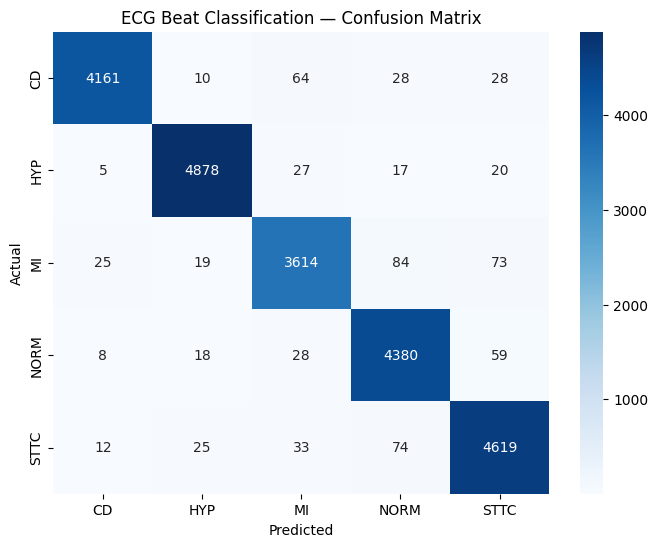

In [16]:
# ==========================================================
# STEP 5 — EVALUATION
# ==========================================================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

y_pred, y_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        out = model(xb)
        y_pred.extend(out.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())

print("\nTEST CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ECG Beat Classification — Confusion Matrix")
plt.show()

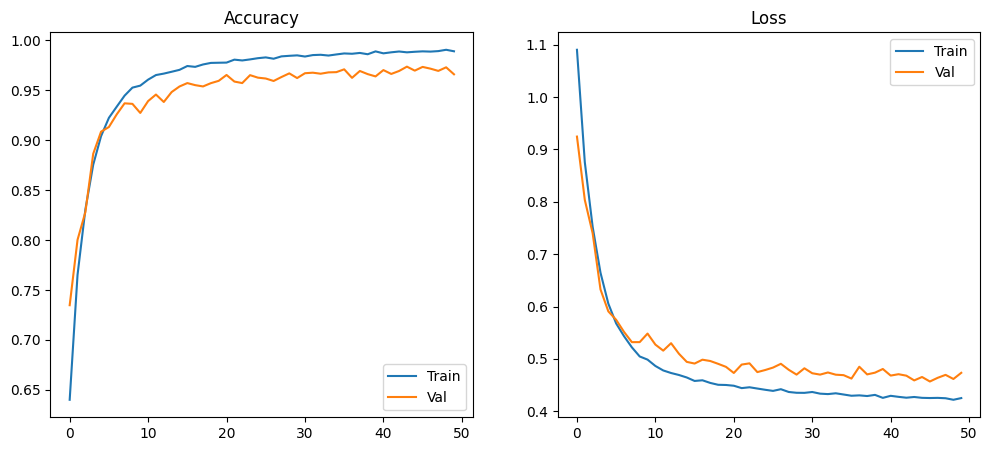

In [17]:
# ==========================================================
# STEP 6 — TRAINING CURVES
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.show()

In [28]:
import torch.nn.functional as F

y_true = []
y_preds = []
y_probs = []   # <-- THIS WAS MISSING

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)

        logits = model(xb)                 # raw outputs
        probs = F.softmax(logits, dim=1)   # probabilities

        y_probs.extend(probs.cpu().numpy())
        y_preds.extend(probs.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())

# Convert to numpy
y_true  = np.array(y_true)
y_preds = np.array(y_preds)
y_probs = np.array(y_probs)

print("Shapes:")
print("y_true :", y_true.shape)
print("y_preds:", y_preds.shape)
print("y_probs:", y_probs.shape)  # (N, num_classes)

Shapes:
y_true : (22309,)
y_preds: (22309,)
y_probs: (22309, 5)


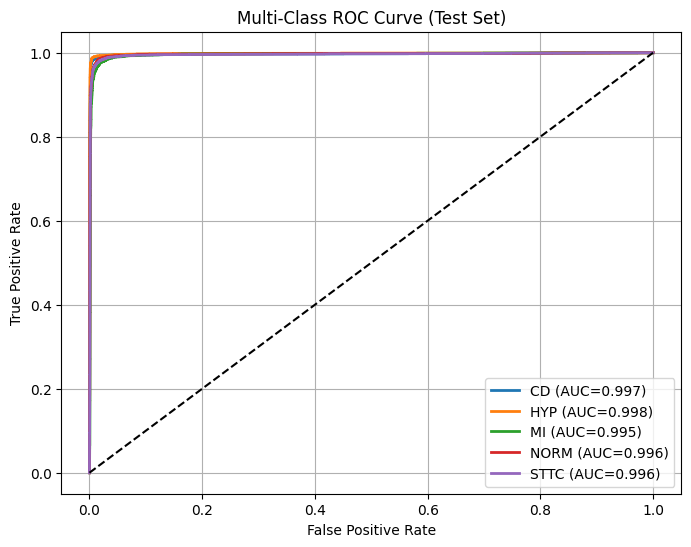

In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# True labels and predicted probabilities
y_true = np.array(y_true)
y_prob = np.array(y_probs)  # shape: (N, num_classes)

n_classes = len(classes)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{classes[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

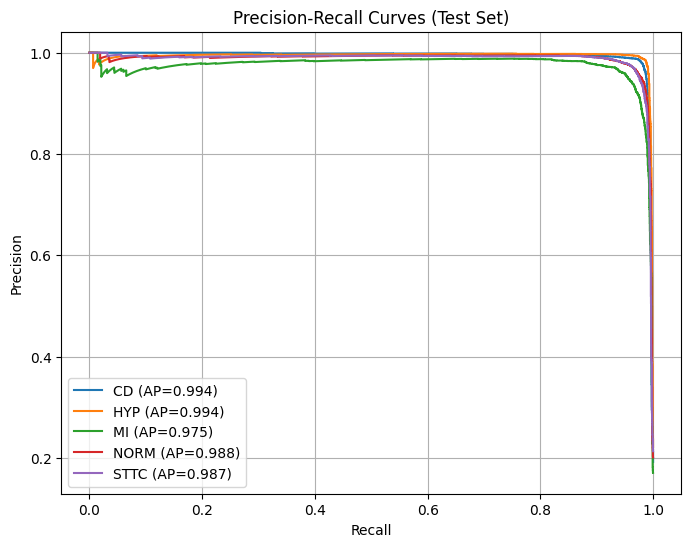

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i], y_prob[:, i]
    )
    ap = average_precision_score(y_true_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f"{classes[i]} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
y_val_true, y_val_preds = [], []

model.eval()
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        outputs = model(xb)
        preds = outputs.argmax(1).cpu().numpy()

        y_val_preds.extend(preds)
        y_val_true.extend(yb.numpy())

y_val_true = np.array(y_val_true)
y_val_preds = np.array(y_val_preds)

print("Validation labels ready")

Validation labels ready


In [33]:
y_test_true, y_test_preds = [], []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        outputs = model(xb)
        preds = outputs.argmax(1).cpu().numpy()

        y_test_preds.extend(preds)
        y_test_true.extend(yb.numpy())

y_test_true = np.array(y_test_true)
y_test_preds = np.array(y_test_preds)

print("Test labels ready")

Test labels ready


In [34]:
val_p, val_r, val_f1 = get_metrics(y_val_true, y_val_preds)
test_p, test_r, test_f1 = get_metrics(y_test_true, y_test_preds)

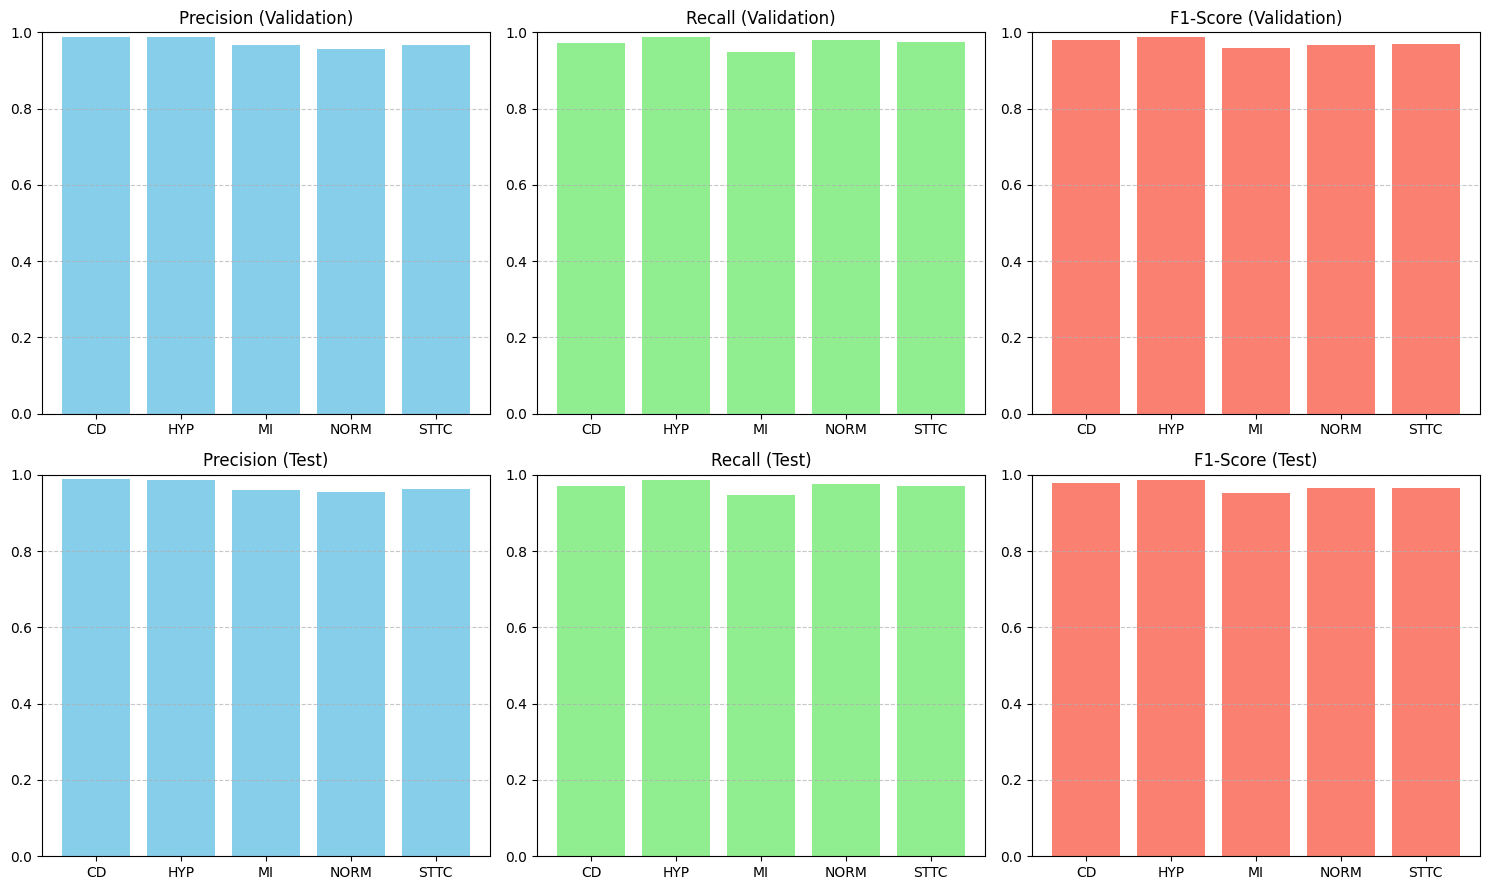

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# --------------------------------------------------
# COMPUTE METRICS
# --------------------------------------------------
def get_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )
    return precision, recall, f1

val_p, val_r, val_f1 = get_metrics(y_val_true, y_val_preds)
test_p, test_r, test_f1 = get_metrics(y_test_true, y_test_preds)

x = np.arange(len(classes))
yticks = np.arange(0.0, 1.01, 0.2)

# --------------------------------------------------
# PLOTTING
# --------------------------------------------------
plt.figure(figsize=(15, 9))

# ================= VALIDATION =================
plt.subplot(2, 3, 1)
plt.bar(x, val_p, color='skyblue')
plt.title("Precision (Validation)")
plt.xticks(x, classes)
plt.yticks(yticks)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 3, 2)
plt.bar(x, val_r, color='lightgreen')
plt.title("Recall (Validation)")
plt.xticks(x, classes)
plt.yticks(yticks)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 3, 3)
plt.bar(x, val_f1, color='salmon')
plt.title("F1-Score (Validation)")
plt.xticks(x, classes)
plt.yticks(yticks)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# ================= TEST =================
plt.subplot(2, 3, 4)
plt.bar(x, test_p, color='skyblue')
plt.title("Precision (Test)")
plt.xticks(x, classes)
plt.yticks(yticks)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 3, 5)
plt.bar(x, test_r, color='lightgreen')
plt.title("Recall (Test)")
plt.xticks(x, classes)
plt.yticks(yticks)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 3, 6)
plt.bar(x, test_f1, color='salmon')
plt.title("F1-Score (Test)")
plt.xticks(x, classes)
plt.yticks(yticks)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()